# FC Analysis

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [18]:
DATA_ROOT = Path("/Users/emmatosato/Local Projects/Local PhD Projects/NEMESIS_fs/data")

# Pre-masking FC data
FC_PRE_DIR = DATA_ROOT / "clinical_connectome/derivatives/UNIPD/WashU/features"

# Masked FC data (e.g. mask_summary)
FC_MASKED_DIR = DATA_ROOT / "derived/features/masked_fc"

# Stacked subjects matrix
FC_MATRIX_DIR = DATA_ROOT / "derived/features/fc_matrix"
atlas_combo = "Yan200TianS2Buckner7N"
n_total_nodes = 239  # nodi totali della mappa cerebrale

## FC features (Pre-Masking)

Prima di analizzare i danni causati dalle lesioni e gli scarti, carichiamo la matrice di Connettività Funzionale (FC) di un singolo paziente direttamente dagli output originari. Questa è la matrice "sana", una griglia perfetta 239x239 che contiene le correlazioni di Pearson tra ogni area cerebrale, senza ancora alcun filtro lesionale applicato.

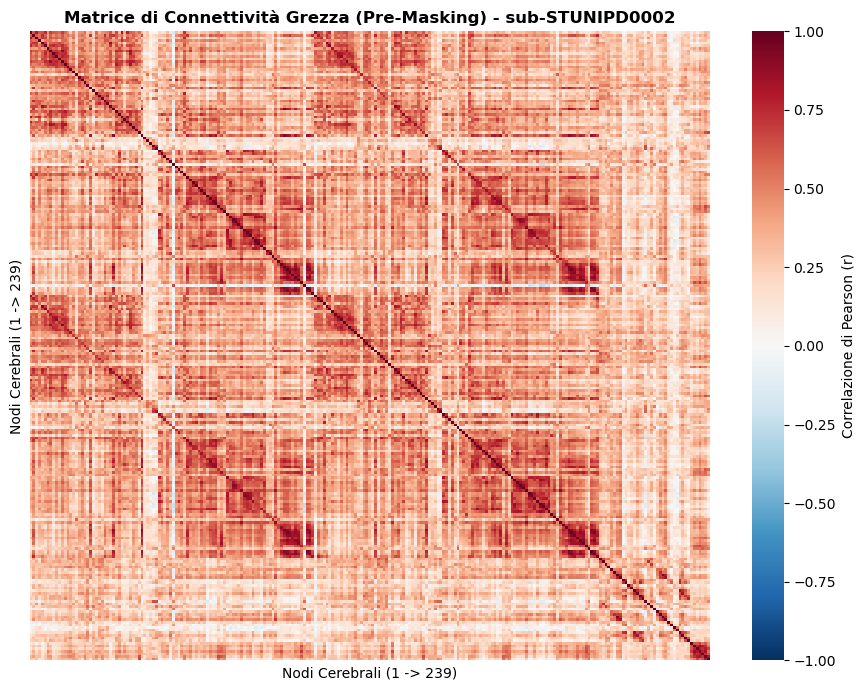

Shape della matrice grezza: (239, 239)
Percentuale di NaN pre-masking: 0.00% (Tutto intatto)


In [19]:
sample_sub_dir = FC_PRE_DIR / "sub-STUNIPD0002" / "func"
sample_fc_file = sample_sub_dir / f"sub-STUNIPD0002_space-MNI152NLin6Asym_FC-pearson_atlas-{atlas_combo}.csv"
if sample_fc_file.exists():
    # La matrice di Pearson grezza 239x239 non ha header
    df_raw_fc = pd.read_csv(sample_fc_file, sep='\t', index_col=0)

    
    plt.figure(figsize=(9, 7))
    # Usiamo una colormap divergente (RdBu_r) perfetta per le correlazioni da -1 a +1
    sns.heatmap(df_raw_fc, cmap="RdBu_r", vmin=-1, vmax=1, center=0, 
                xticklabels=False, yticklabels=False, 
                cbar_kws={'label': 'Correlazione di Pearson (r)'})
    
    plt.title(f"Matrice di Connettività Grezza (Pre-Masking) - sub-STUNIPD0002", fontweight='bold')
    plt.xlabel("Nodi Cerebrali (1 -> 239)")
    plt.ylabel("Nodi Cerebrali (1 -> 239)")
    plt.tight_layout()
    plt.show()
    
    print(f"Shape della matrice grezza: {df_raw_fc.shape}")
    print(f"Percentuale di NaN pre-masking: {df_raw_fc.isna().mean().mean() * 100:.2f}% (Tutto intatto)")
else:
    print(f"File raw non trovato: {sample_fc_file}")

## FC Masked with Lesions

### Loading

Questo file dice, per ognuno dei 169 pazienti, quanti nodi (su 239 totali della mappa cerebrale) hanno una lesione troppo estesa per fidarsi della loro connettività — cioè quanti nodi sono stati marcati come "compromessi" secondo la soglia descritta in fc_lesion_masking.md (meno del 50% di tessuto sano).

In [20]:
mask_summary_path = FC_MASKED_DIR / atlas_combo / "mask_summary.csv"
df_mask_summary = pd.read_csv(mask_summary_path)
print(f"Pazienti nel run reale: {len(df_mask_summary)}")
display(df_mask_summary.head())
display(df_mask_summary["n_compromised_nodes"].describe())

Pazienti nel run reale: 169


,subject_id,n_compromised_nodes
0,sub-STUNIPD0002,0
1,sub-STUNIPD0003,8
2,sub-STUNIPD0005,2
3,sub-STUNIPD0006,9
4,sub-STUNIPD0008,0


count    169.000000
mean       3.881657
std        6.705379
min        0.000000
25%        0.000000
50%        1.000000
75%        5.000000
max       42.000000
Name: n_compromised_nodes, dtype: float64

### Distribuzione Istogrammi e Tabella Percentili

Nodo = Parcella

La maggior parte dei pazienti ha pochissimi nodi compromessi.

Se la distribuzione fosse piatta (tanti pazienti sparsi su tutti i valori), una soglia sarebbe una scelta delicata. Guardiamo se invece c'è una massa di pazienti "puliti" e una coda di pochi pazienti molto compromessi — in quel caso la soglia taglierebbe solo la coda, con poco rischio di perdere dati buoni.

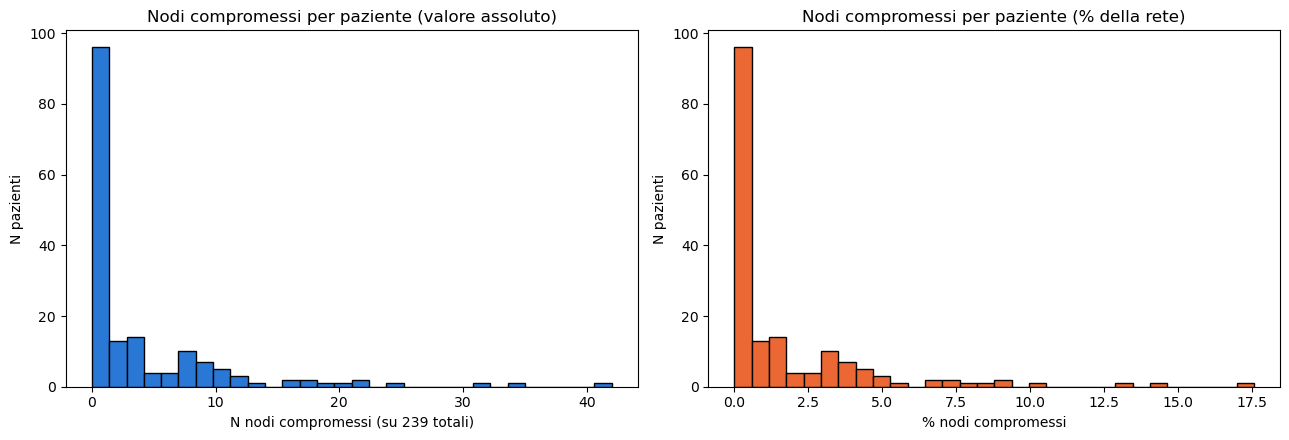


📊 PERCENTILI DEI NODI COMPROMESSI NELLA COORTE:


,p50,p75,p90,p95,p99,p100
Nodi Compromessi,1,5,11,17,31,42


In [ ]:
SERIES_BLUE = "#2a78d6"
SERIES_ORANGE = "#eb6834"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(df_mask_summary["n_compromised_nodes"], bins=30, edgecolor="black", color=SERIES_BLUE)
axes[0].set_title("Nodi compromessi per paziente (valore assoluto)")
axes[0].set_xlabel(f"N nodi compromessi (su {n_total_nodes} totali)")
axes[0].set_ylabel("N pazienti")

axes[1].hist(df_mask_summary["n_compromised_nodes"] / n_total_nodes * 100, bins=30, edgecolor="black", color=SERIES_ORANGE)
axes[1].set_title("Nodi compromessi per paziente (% della rete)")
axes[1].set_xlabel("% nodi compromessi")
axes[1].set_ylabel("N pazienti")

plt.tight_layout()
plt.show()

# --- Tabella dei Percentili elegante ---
print("\nPERCENTILI DEI NODI COMPROMESSI NELLA COORTE:")
percentiles = [50, 75, 90, 95, 99, 100]
pct_table = df_mask_summary["n_compromised_nodes"].quantile([p / 100 for p in percentiles]).astype(int)
pct_table.index = [f"p{p}" for p in percentiles]

df_pct = pd.DataFrame(pct_table).T
df_pct.index = ["Nodi Compromessi"]
display(df_pct)


Un percentile risponde alla domanda "sotto quale valore sta il P% dei pazienti?". 

Es. p90 = 11 significa che il 90% dei 169 pazienti ha al massimo 11 nodi compromessi — solo il 10% (~17 pazienti) ne ha di più. 

Andando verso p95/p99/p100 ci si avvicina sempre più alla coda estrema della distribuzione (i pazienti più compromessi), fino al singolo valore massimo osservato (p100). 

Servono a capire quanto "in profondità nella coda" entreremmo scegliendo una soglia — non a decidere se tagliare una massa consistente di pazienti nella norma.

### Analisi delle Soglie

Vediamo l'intera curva: per ogni soglia possibile (n nodi compromessi oltre cui un paziente verrebbe escluso), quanti pazienti restano fuori.

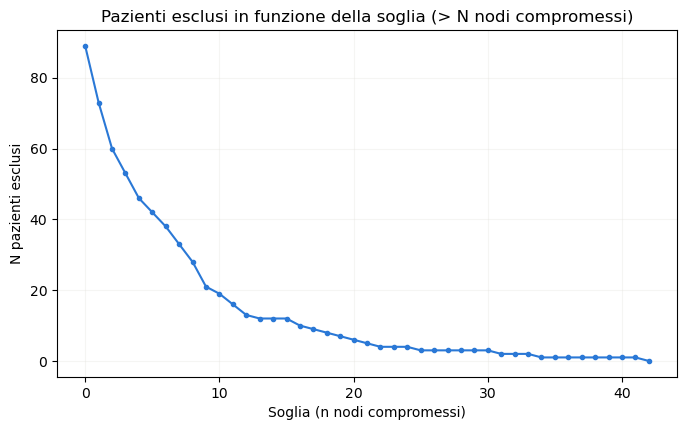

,soglia_nodi,soglia_%_rete,pazienti_esclusi,pazienti_rimasti
0,5,2.1,42,127
1,10,4.2,19,150
2,12,5.0,13,156
3,15,6.3,12,157
4,20,8.4,6,163
5,24,10.0,4,165
6,30,12.6,3,166
7,40,16.7,1,168


In [23]:
n_patients = len(df_mask_summary)
max_nodes = int(df_mask_summary["n_compromised_nodes"].max())
thresholds = np.arange(0, max_nodes + 1)
n_excluded = [(df_mask_summary["n_compromised_nodes"] > thr).sum() for thr in thresholds]

plt.figure(figsize=(8, 4.5))
plt.plot(thresholds, n_excluded, marker="o", markersize=3, color=SERIES_BLUE)
plt.title("Pazienti esclusi in funzione della soglia (> N nodi compromessi)")
plt.xlabel("Soglia (n nodi compromessi)")
plt.ylabel("N pazienti esclusi")
plt.grid(alpha=0.3, color="#e1e0d9")
plt.show()

candidate_thresholds = [5, 10, 12, 15, 20, 24, 30, 40]
summary_df = pd.DataFrame({
    "soglia_nodi": candidate_thresholds,
    "soglia_%_rete": [round(t / n_total_nodes * 100, 1) for t in candidate_thresholds],
    "pazienti_esclusi": [(df_mask_summary["n_compromised_nodes"] > t).sum() for t in candidate_thresholds],
})
summary_df["pazienti_rimasti"] = n_patients - summary_df["pazienti_esclusi"]
display(summary_df)

Ogni riga rappresenta **una possibile soglia candidata** — non sono soglie già scelte, solo ipotesi da confrontare prima di deciderne una.

- **`soglia_nodi`**: la regola "escludi un paziente se ha più di questo numero di nodi compromessi" (su 239 nodi totali della mappa cerebrale).
- **`soglia_%_rete`**: la stessa identica soglia, espressa come percentuale del totale dei nodi (`soglia_nodi ÷ 239 × 100`) — utile per confrontare soglie su atlanti diversi, che hanno un numero di nodi totali diverso.
- **`pazienti_esclusi`**: quanti dei 169 pazienti verrebbero tolti dalla matrice finale, applicando quella soglia.
- **`pazienti_rimasti`**: quanti pazienti resterebbero (169 − `pazienti_esclusi`).

**Esempio concreto, riga per riga — soglia 12 nodi (5.0%)**: applicando la regola "escludi chi ha più di 12 nodi compromessi", 13 pazienti su 169 verrebbero esclusi (quelli con 13, 14, ..., fino a 42 nodi compromessi), e ne resterebbero 156.

**Il pattern generale lungo la tabella**: più si alza la soglia (righe verso il basso), meno pazienti vengono esclusi — perché una soglia più alta è più "permissiva" (tollera pazienti più compromessi). Il salto tra una riga e l'altra non è costante: tra soglia 10→12 si passa da 19 a 13 esclusi (salto di 6), mentre tra 12→15 si passa da 13 a 12 (salto di 1 solo) — segno che oltre soglia ~12 si è già usciti dalla parte "densa" della distribuzione ed entrati nella coda rara di pochi pazienti molto compromessi.


### Dai Nodi Compromessi alle Connessioni Perse


Se un nodo è compromesso, tutte le sue connessioni con il resto della rete diventano NaN — fino a 238 connessioni perse per un solo nodo (su una rete di 239). Quindi "3 nodi compromessi" può voler dire poche decine di NaN o molte centinaia, a seconda di quali nodi sono coinvolti.

*Esempio:* 

Con un atlante giocattolo a 4 zone (A, B, C, D) ci sono 6 connessioni possibili in totale (A-B, A-C, A-D, B-C, B-D, C-D). 
Se solo la zona C è compromessa, diventano NaN tutte le connessioni che la coinvolgono — A-C, B-C, C-D — cioè 3 connessioni su 6 (50%), pur essendo compromessa 1 sola zona su 4. 

Nei dati reali (239 zone), un singolo nodo compromesso costa allo stesso modo fino a 238 connessioni su 28.441 totali — e se più zone sono compromesse insieme, il conteggio non è nemmeno una semplice somma (connessioni condivise, come C-D se sia C che D fossero compromesse, si contano una volta sola).

Guardiamo quindi la relazione reale tra nodi compromessi (proxy) e % di connessioni perse nella matrice finale (metrica esatta), per capire se contare i nodi è già una buona proxy o se serve guardare direttamente i NaN.

Matrice FC finale: 169 pazienti x 28441 connessioni
Frazione NaN sull'intera matrice: 0.0356


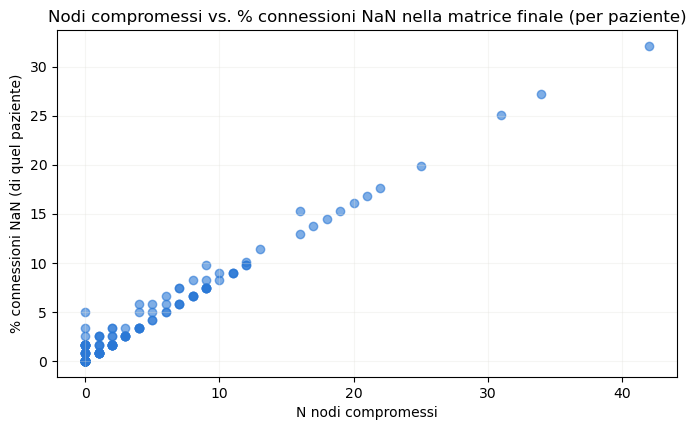

,subject_id,nan_edge_fraction_%,n_compromised_nodes
74,sub-STUNIPD0105,32.119124,42
73,sub-STUNIPD0104,27.196653,34
98,sub-STUNIPD0150,25.034281,31
133,sub-STUNIPD0202,19.865687,25
167,sub-STUNIPD0248,17.597834,22
168,sub-STUNIPD0250,16.834851,21
156,sub-STUNIPD0234,16.068352,20
134,sub-STUNIPD0203,15.298337,19
75,sub-STUNIPD0109,14.524806,18
163,sub-STUNIPD0242,13.747759,17


In [26]:
# Usiamo FC_MATRIX_DIR (che punta già alla cartella giusta) e la slash "/" di pathlib
matrix_path = FC_MATRIX_DIR / atlas_combo / "24-07_s2"

# Carica la matrice vera e propria: solo numeri, 169 righe (pazienti) x 28441 colonne (connessioni)
fc_matrix = np.load(matrix_path / "matrix.npy")
df_fc_meta = pd.read_csv(matrix_path / "metadata.csv")

# Stampa le dimensioni reali della matrice 
print(f"Matrice FC finale: {fc_matrix.shape[0]} pazienti x {fc_matrix.shape[1]} connessioni")
# np.isnan(...) trasforma ogni numero in Vero/Falso ("è NaN?"); .mean() su TUTTA la matrice
print(f"Frazione NaN sull'intera matrice: {np.isnan(fc_matrix).mean():.4f}")

# per ogni singolo paziente, che % delle sue 28441 connessioni è NaN
nan_fraction_per_subject = np.isnan(fc_matrix).mean(axis=1) * 100

df_nan = df_fc_meta.copy()
df_nan["nan_edge_fraction_%"] = nan_fraction_per_subject
# in ogni riga ha SIA i nodi compromessi SIA la % NaN reale, per lo stesso paziente
df_nan = df_nan.merge(df_mask_summary, on="subject_id", how="left")


plt.figure(figsize=(8, 4.5))
plt.scatter(df_nan["n_compromised_nodes"], df_nan["nan_edge_fraction_%"], alpha=0.6, color=SERIES_BLUE)
plt.title("Nodi compromessi vs. % connessioni NaN nella matrice finale (per paziente)")
plt.xlabel("N nodi compromessi")
plt.ylabel("% connessioni NaN (di quel paziente)")
plt.grid(alpha=0.3, color="#e1e0d9")
plt.show()

display(df_nan.sort_values("n_compromised_nodes", ascending=False).head(10))


Grafico a dispersione: un puntino per paziente. 
- Asse orizzontale = nodi compromessi (da prima),
- Asse verticale = % NaN reale (appena calcolata) 

Ordina i pazienti dal più compromesso al meno, mostra i primi 10 -> "classifica" dei candidati più forti all'esclusione, con accanto il dato NaN reale corrispondente